=============================================================================
Notebook 05: Integrated Analysis — Cross-Layer Data Gap Assessment
Global Nutrition Monitoring Framework — UNICEF Conceptual Framework Project
Adam T. Bailes, MPH | August 2026
=============================================================================

PURPOSE
-------
Integrate all three layers into a summary analysis:
  - Comprehensive data gap matrix across all layers
  - Country-level nutrition information system readiness score
  - Regional summaries for Tableau dashboard
  - Key findings narrative table

This integrated view is the core portfolio demonstration: showing that
a national nutrition information system assessment must look across
outcomes, determinants, AND enabling environment simultaneously — not
just track a single indicator category.
=============================================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_PROC = '../data/processed'
FIGURES   = '../outputs/figures'
TABLES    = '../outputs/tables'

In [3]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 150
})

In [4]:
UNICEF_BLUE   = '#1CABE2'
UNICEF_NAVY   = '#374EA2'
UNICEF_GREEN  = '#00833D'
UNICEF_ORANGE = '#F26A21'
UNICEF_RED    = '#E2231A'

In [5]:
print("=" * 70)
print("NOTEBOOK 05: INTEGRATED ANALYSIS — CROSS-LAYER DATA GAP ASSESSMENT")
print("=" * 70)

NOTEBOOK 05: INTEGRATED ANALYSIS — CROSS-LAYER DATA GAP ASSESSMENT


In [6]:
# --- Load all processed data ---
try:
    df_latest = pd.read_csv(f'{DATA_PROC}/latest_values_by_country.csv')
    df_gap    = pd.read_csv(f'{DATA_PROC}/data_gap_matrix.csv')
    df_l3     = pd.read_csv(f'{TABLES}/layer3_enabling_environment_toolkit.csv')
except FileNotFoundError as e:
    print(f"ERROR: {e}")
    print("Run notebooks 01-04 first.")
    raise

In [7]:
# All UNICEF SDMX indicators used across layers
ALL_INDICATORS = {
    # Layer 1
    'NT_ANT_HAZ_NE2_MOD':   ('Layer 1', 'Stunting'),
    'NT_ANT_WHZ_NE2_MOD':   ('Layer 1', 'Wasting'),
    'NT_ANT_WHZ_PO2_MOD':   ('Layer 1', 'Overweight'),
    'NT_ANE_WOM_15_49_MOD': ('Layer 1', 'Anaemia WRA'),
    'NT_BF_EXBF':           ('Layer 1', 'Excl. BF'),
    'NT_BW_LBW':            ('Layer 1', 'Low Birth Weight'),
    # Layer 2 — IYCF
    'NT_BF_EIBF':           ('Layer 2', 'Early BF Initiation'),
    'NT_CF_MDD':            ('Layer 2', 'Min Dietary Diversity'),
    'NT_CF_MMF':            ('Layer 2', 'Min Meal Frequency'),
    'NT_CF_MAD':            ('Layer 2', 'Min Acceptable Diet'),
    'NT_BF_CBF12_23':       ('Layer 2', 'Continued BF 12-23m'),
    # Layer 2 — Services
    'MNCH_ANC4':            ('Layer 2', 'ANC 4+ Visits'),
    'MNCH_SAB':             ('Layer 2', 'Skilled Birth Attendance'),
    'IM_DTP3':              ('Layer 2', 'DTP3 Coverage'),
    'NT_SAM_TR':            ('Layer 2', 'SAM Treatment'),
    'NT_VAS_12_59':         ('Layer 2', 'Vitamin A Supp.'),
}

=============================================================================
FIGURE 8: Comprehensive data gap heatmap — all countries, all indicators
=============================================================================

In [8]:
print("\n[1] Generating comprehensive data gap heatmap...")


[1] Generating comprehensive data gap heatmap...


In [9]:
# Build gap matrix: years since most recent data per country per indicator
df_latest['indicator_info'] = df_latest['indicator'].map(
    lambda x: ALL_INDICATORS.get(x, (None, x))
)
df_latest['layer'] = df_latest['indicator_info'].apply(
    lambda x: x[0] if isinstance(x, tuple) else None)
df_latest['indicator_short'] = df_latest['indicator_info'].apply(
    lambda x: x[1] if isinstance(x, tuple) else x)

In [10]:
df_sdmx = df_latest[df_latest['indicator'].isin(ALL_INDICATORS.keys())].copy()
df_sdmx['years_since'] = 2024 - df_sdmx['year'].fillna(2000)
df_sdmx['years_since'] = df_sdmx['years_since'].clip(0, 20)

In [11]:
# Regional summary heatmap (countries × indicators too large for one chart)
region_gap = df_sdmx.pivot_table(
    index='region',
    columns='indicator_short',
    values='years_since',
    aggfunc='median'
).round(1)

In [12]:
# Reorder columns by layer
col_order = [v[1] for k, v in ALL_INDICATORS.items()
             if v[1] in region_gap.columns]
region_gap = region_gap[[c for c in col_order if c in region_gap.columns]]

In [13]:
# Add layer dividers — mark columns by layer
layer1_cols = [v[1] for k, v in ALL_INDICATORS.items()
               if v[0] == 'Layer 1' and v[1] in region_gap.columns]
layer2_cols = [v[1] for k, v in ALL_INDICATORS.items()
               if v[0] == 'Layer 2' and v[1] in region_gap.columns]

<Axes: xlabel='indicator_short', ylabel='region'>

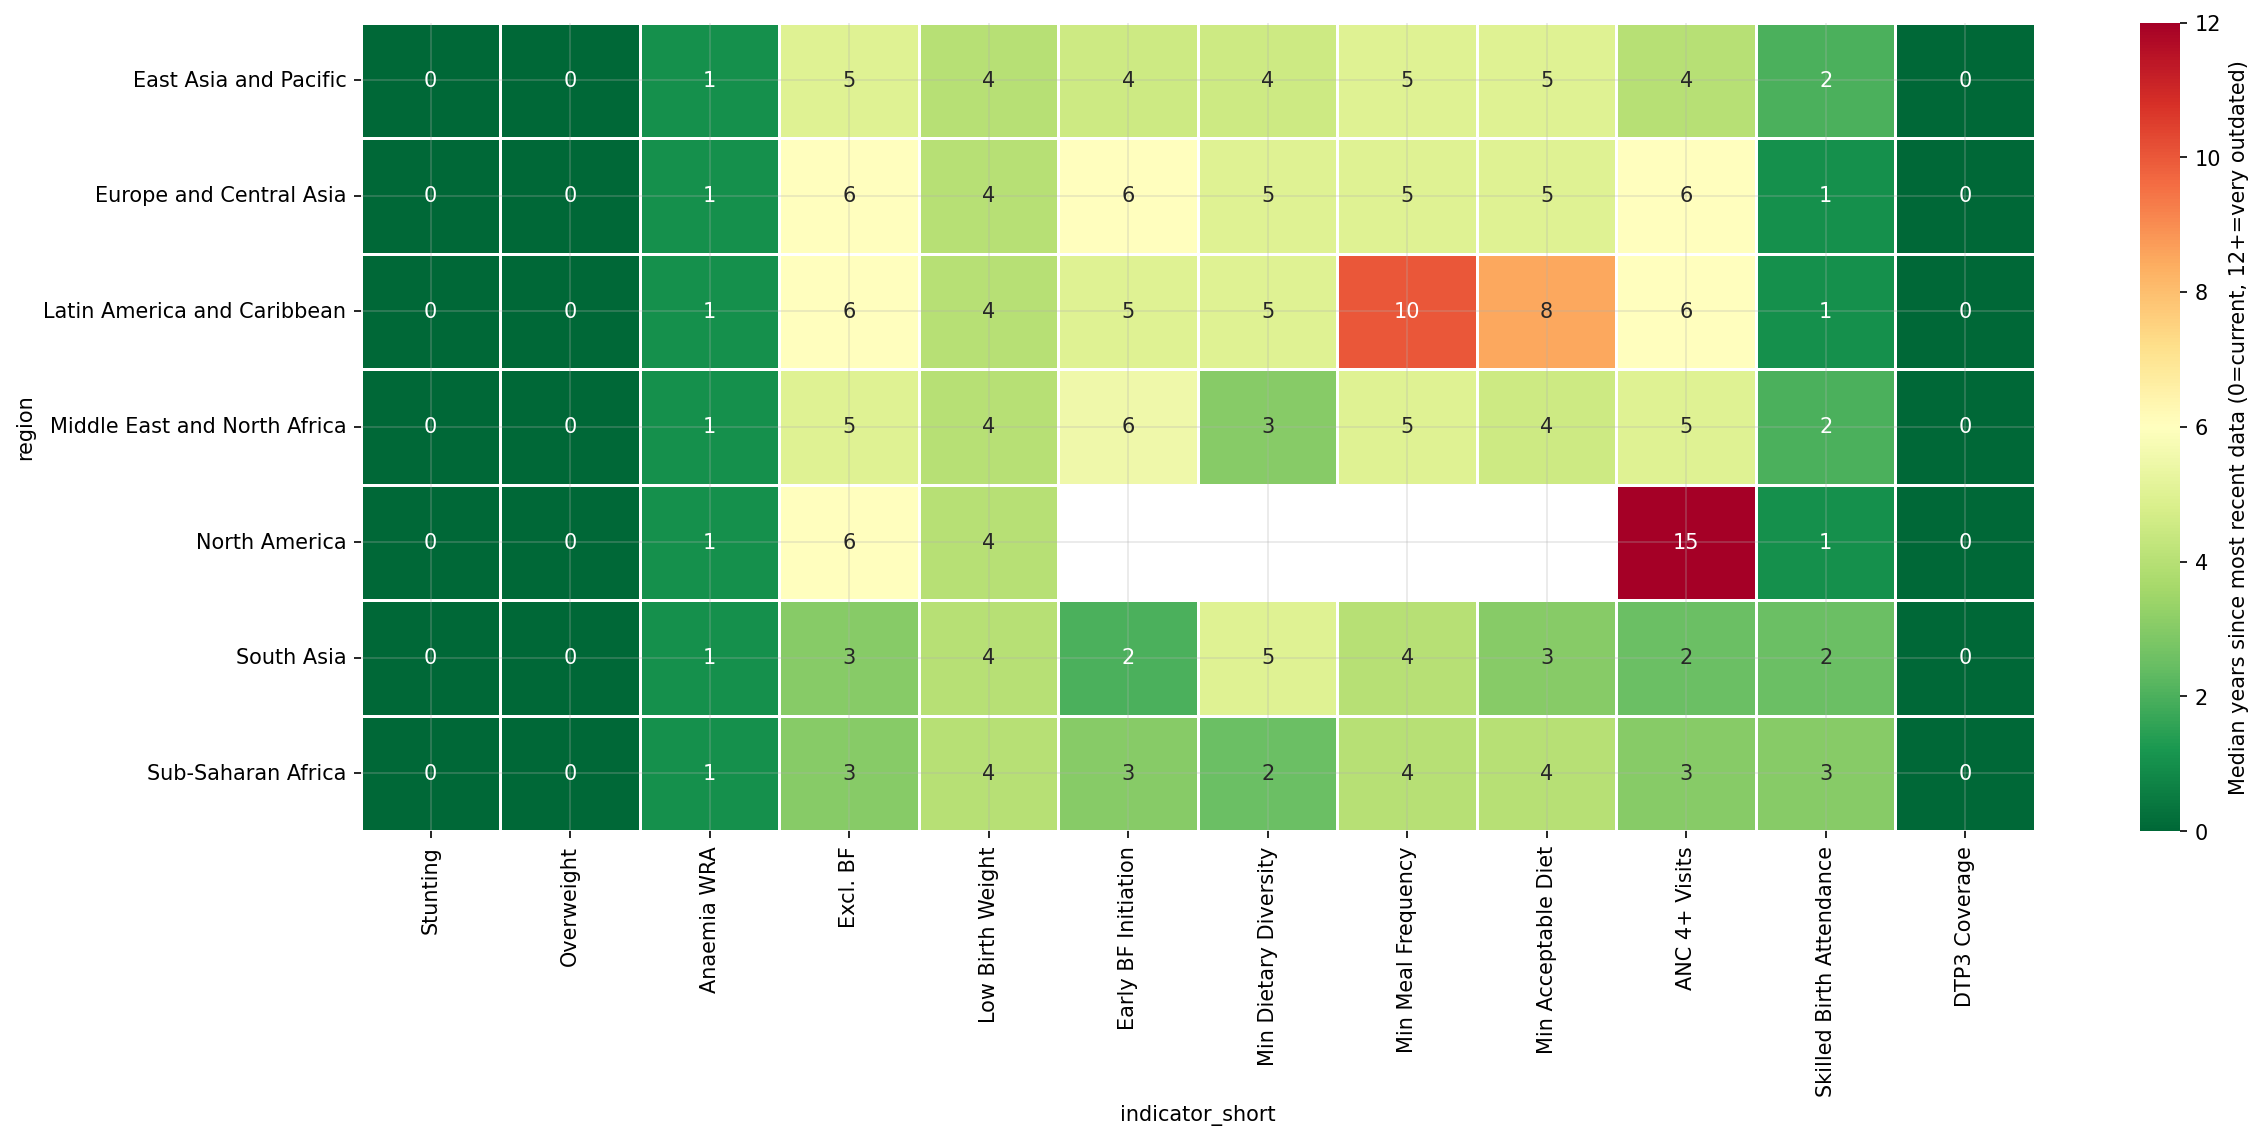

In [14]:
fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    region_gap,
    annot=True, fmt='.0f',
    cmap='RdYlGn_r',
    vmin=0, vmax=12,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Median years since most recent data (0=current, 12+=very outdated)'}
)

In [15]:
# Add layer divider lines
n_l1 = len(layer1_cols)
ax.axvline(x=n_l1, color='black', linewidth=2.5)

In [16]:
# Layer labels above
ax.text(n_l1 / 2, -0.8, 'LAYER 1: OUTCOMES (WHA 6 Targets)',
        ha='center', va='top', fontsize=9, fontweight='bold',
        color=UNICEF_NAVY, transform=ax.transData)
ax.text(n_l1 + len(layer2_cols) / 2, -0.8, 'LAYER 2: UNDERLYING DETERMINANTS',
        ha='center', va='top', fontsize=9, fontweight='bold',
        color=UNICEF_BLUE, transform=ax.transData)

Text(8.5, -0.8, 'LAYER 2: UNDERLYING DETERMINANTS')

In [17]:
ax.set_title(
    'National Nutrition Information System — Data Recency by Region and Indicator\n'
    'UNICEF Conceptual Framework: Layers 1 and 2 (UNICEF SDMX data, 2024)',
    fontweight='bold', pad=20
)
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=35, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=9)

In [18]:
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig08_comprehensive_gap_heatmap.png',
            bbox_inches='tight', dpi=150)
plt.show()
plt.close()
print("  Saved: fig08_comprehensive_gap_heatmap.png")

<Figure size 960x720 with 0 Axes>

  Saved: fig08_comprehensive_gap_heatmap.png


=============================================================================
FIGURE 9: Country NIS Readiness Score
=============================================================================

In [19]:
print("\n[2] Calculating country NIS readiness scores...")


[2] Calculating country NIS readiness scores...


Score = % of indicators with data ≤5 years old, per country
Weighted by layer importance

In [20]:
LAYER_WEIGHTS = {'Layer 1': 0.50, 'Layer 2': 0.50}

In [21]:
country_scores = []

In [22]:
for country_iso in df_sdmx['iso3'].unique():
    df_c = df_sdmx[df_sdmx['iso3'] == country_iso]
    country_name = df_c['country'].iloc[0] if 'country' in df_c.columns else country_iso
    region = df_c['region'].iloc[0] if 'region' in df_c.columns else 'Unknown'
    income = df_c['income_group'].iloc[0] if 'income_group' in df_c.columns else 'Unknown'

    scores_by_layer = {}
    for layer in ['Layer 1', 'Layer 2']:
        layer_codes = [k for k, v in ALL_INDICATORS.items() if v[0] == layer]
        df_cl = df_c[df_c['indicator'].isin(layer_codes)]
        n_total = len(layer_codes)
        n_recent = len(df_cl[df_cl['years_since'] <= 5])
        scores_by_layer[layer] = (n_recent / n_total * 100) if n_total > 0 else 0

    total_score = sum(scores_by_layer.get(l, 0) * w
                      for l, w in LAYER_WEIGHTS.items())

    country_scores.append({
        'iso3':         country_iso,
        'country':      country_name,
        'region':       region,
        'income_group': income,
        'layer1_score': scores_by_layer.get('Layer 1', 0),
        'layer2_score': scores_by_layer.get('Layer 2', 0),
        'nis_readiness_score': total_score,
    })

In [23]:
df_scores = pd.DataFrame(country_scores).sort_values('nis_readiness_score',
                                                       ascending=False)
df_scores.to_csv(f'{TABLES}/country_nis_readiness_scores.csv', index=False)
print(f"  Calculated scores for {len(df_scores)} countries")

  Calculated scores for 375 countries


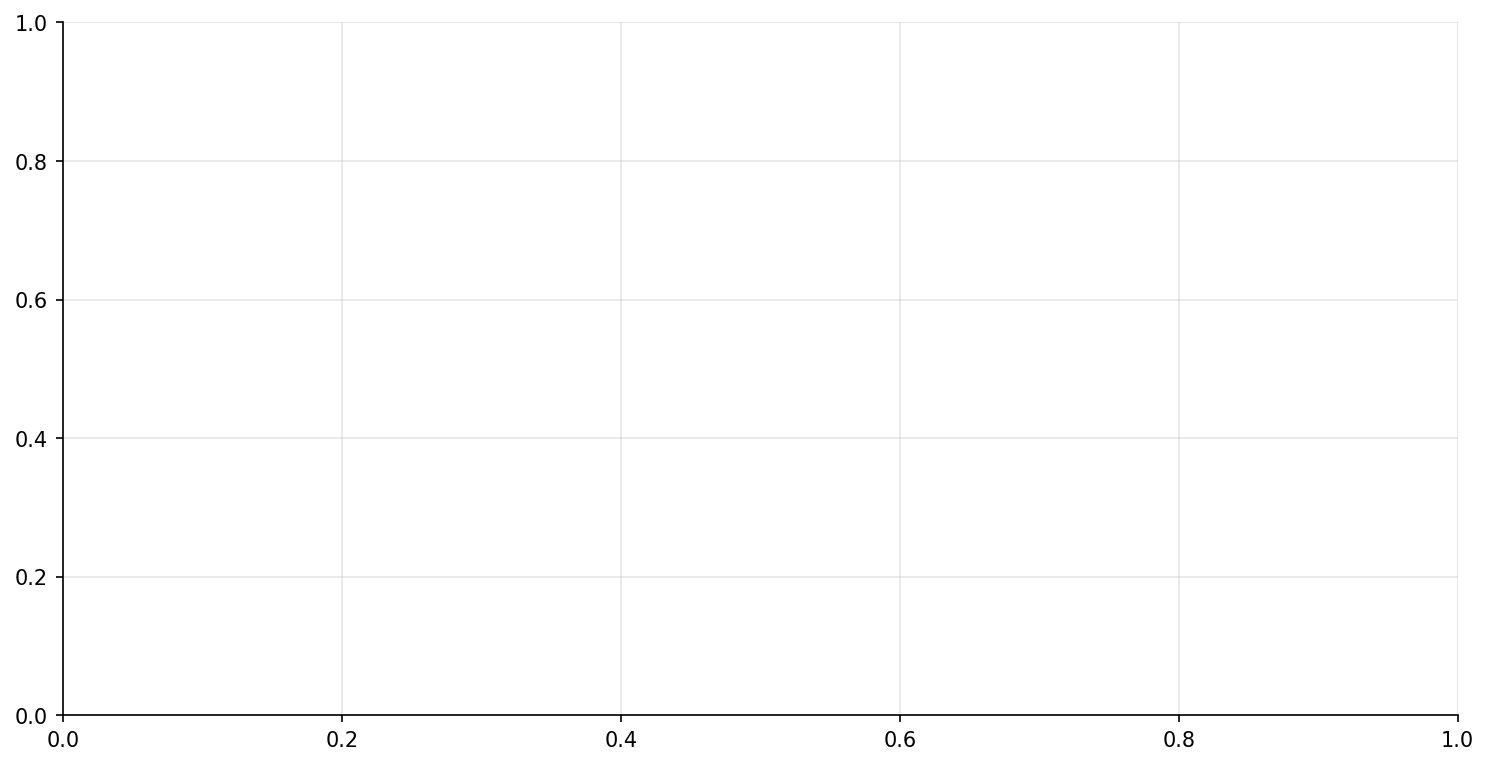

In [24]:
# Plot: distribution of NIS readiness by region
fig, ax = plt.subplots(figsize=(12, 6))

In [25]:
region_score = (df_scores.groupby('region')['nis_readiness_score']
                .agg(['median', 'mean', 'count'])
                .reset_index()
                .sort_values('median', ascending=True))

In [26]:
REGION_COLORS = {
    'Eastern and Southern Africa':  UNICEF_BLUE,
    'West and Central Africa':      UNICEF_ORANGE,
    'South Asia':                   '#6A1E74',
    'East Asia and Pacific':        UNICEF_GREEN,
    'Middle East and North Africa': '#E8A838',
    'Latin America and Caribbean':  '#00AED9',
    'Europe and Central Asia':      '#80BD41',
    'North America':                '#999999',
}

In [27]:
colors = [REGION_COLORS.get(r, '#AAAAAA')
          for r in region_score['region']]

In [28]:
bars = ax.barh(range(len(region_score)), region_score['median'],
               color=colors, alpha=0.85, edgecolor='white')

In [29]:
for i, (_, row) in enumerate(region_score.iterrows()):
    ax.text(row['median'] + 1, i, f"{row['median']:.0f}% (n={row['count']:.0f})",
            va='center', fontsize=8)

In [30]:
ax.set_yticks(range(len(region_score)))
ax.set_yticklabels(region_score['region'].str.replace(' and ', ' & '),
                   fontsize=9)
ax.set_xlabel('Median NIS Readiness Score\n(% of indicators with recent data ≤5 years)',
              fontsize=10)
ax.set_title(
    'National Nutrition Information System Readiness by Region\n'
    'Based on Data Recency Across GNMF Indicator Set',
    fontweight='bold'
)
ax.axvline(50, color='red', linestyle='--', alpha=0.5,
           linewidth=1.2, label='50% threshold')
ax.set_xlim(0, 115)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig09_nis_readiness_by_region.png',
            bbox_inches='tight', dpi=150)
plt.show()
plt.close()
print("  Saved: fig09_nis_readiness_by_region.png")

<Figure size 960x720 with 0 Axes>

  Saved: fig09_nis_readiness_by_region.png


=============================================================================
MASTER TABLEAU EXPORT
=============================================================================

In [31]:
print("\n[3] Building master Tableau export...")


[3] Building master Tableau export...


In [32]:
# Full long-format dataset for Tableau
tableau_master = df_sdmx[[
    'iso3', 'country', 'year', 'indicator', 'indicator_short',
    'layer', 'value', 'years_since', 'region', 'income_group'
]].copy()

In [33]:
tableau_master = tableau_master.merge(
    df_scores[['iso3', 'nis_readiness_score', 'layer1_score', 'layer2_score']],
    on='iso3', how='left'
)

In [34]:
tableau_master.to_csv(f'{TABLES}/tableau_master_all_layers.csv', index=False)

In [35]:
# Key findings summary
key_findings = pd.DataFrame([
    {
        'Finding': 'Global stunting still 23.2% (2024)',
        'Layer': 'Layer 1', 'Indicator': 'Stunting',
        'Source': 'UNICEF/WHO/WB JME 2025',
        'Implication': 'Pace of decline insufficient for 2030 ≤10% target'
    },
    {
        'Finding': 'EBF at 47.8% globally (2023)',
        'Layer': 'Layer 1', 'Indicator': 'Exclusive BF',
        'Source': 'UNICEF IYCF Database',
        'Implication': 'Progress needed to reach 60% by 2030'
    },
    {
        'Finding': 'MDD coverage only 34% of children 6-23m',
        'Layer': 'Layer 2', 'Indicator': 'Min. Dietary Diversity',
        'Source': 'SOFI 2025 / UNICEF IYCF Database',
        'Implication': 'New SDG 2.2.4 indicator — countries need guidance to collect'
    },
    {
        'Finding': 'Anaemia in WRA worsening — 30.7% (2023)',
        'Layer': 'Layer 1', 'Indicator': 'Anaemia WRA',
        'Source': 'WHO Global Anaemia Estimates',
        'Implication': 'Off track for 50% reduction target'
    },
    {
        'Finding': 'Data gaps largest for SAM treatment coverage',
        'Layer': 'Layer 2', 'Indicator': 'SAM Treatment',
        'Source': 'Data gap analysis — this project',
        'Implication': 'NutriDash administrative data not yet standardized globally'
    },
    {
        'Finding': 'Enabling environment data most fragmented',
        'Layer': 'Layer 3', 'Indicator': 'Policy/governance',
        'Source': 'WHO GINA, SUN, ILO — varied coverage',
        'Implication': 'No single source; new guide must address this explicitly'
    },
])
key_findings.to_csv(f'{TABLES}/key_findings_summary.csv', index=False)

In [36]:
print(f"  Saved: tableau_master_all_layers.csv ({len(tableau_master):,} rows)")
print(f"  Saved: key_findings_summary.csv")

  Saved: tableau_master_all_layers.csv (3,373 rows)
  Saved: key_findings_summary.csv


In [37]:
print("\n" + "=" * 70)
print("ALL NOTEBOOKS COMPLETE")
print("=" * 70)
print("""
NEXT STEPS:
  1. Open Tableau Public Desktop
  2. Connect to data: outputs/tables/tableau_master_all_layers.csv
  3. Build dashboard pages:
       Page 1: Framework Overview (layer structure diagram)
       Page 2: WHA 6 Targets — World Map + Progress Chart
       Page 3: IYCF Indicators — Regional Dashboard
       Page 4: Health Services Coverage — Bar Charts
       Page 5: Data Gap Heatmap — Full NIS Assessment
       Page 6: Enabling Environment Toolkit — Reference Table
  4. Publish to Tableau Public
  5. Add Tableau link to GitHub README
""")


ALL NOTEBOOKS COMPLETE

NEXT STEPS:
  1. Open Tableau Public Desktop
  2. Connect to data: outputs/tables/tableau_master_all_layers.csv
  3. Build dashboard pages:
       Page 1: Framework Overview (layer structure diagram)
       Page 2: WHA 6 Targets — World Map + Progress Chart
       Page 3: IYCF Indicators — Regional Dashboard
       Page 4: Health Services Coverage — Bar Charts
       Page 5: Data Gap Heatmap — Full NIS Assessment
       Page 6: Enabling Environment Toolkit — Reference Table
  4. Publish to Tableau Public
  5. Add Tableau link to GitHub README

